# PINN-Slicer: Figure & Table Reproduction

This notebook reproduces the figures and tables in "PINN-Slicer: Exploiting Rotational Symmetry to Solve the Photon Orbit Equation around a Black Hole"
(submitted to ML4PS 2026).

Note: Figures 1 and 5 (schematics) were created outside this notebook
and are not reproduced here.

Commit at submission: ______TODO______

## Setup

### Fetch GitHub repository
**TODO**: change with anonymous github

In [1]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# The package was renamed from pinn4bhoc to pinnslicer (commit 6292b31);
# the clone and the import below both use the current name.
# TODO: change with anonymous github
if IN_COLAB:
    if not os.path.exists('pinnslicer'):
        !git clone -q https://github.com/soot-bit/pinnslicer.git
    !pip install -q -e ./pinnslicer


### Imports

In [2]:
from pathlib import Path

import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
import torch

# --- project package: pinnslicer ---
import pinnslicer
import pinnslicer.nn as mlp

# Conversion (r, delta) → (u0, v0), and the boomerang orbit parameters
from pinnslicer.orbits.orbit_setup import compute_u0_v0, INIT_COND, U0, V0, COLOR

# Solvers: both are callables (y0, phi) → OrbitSolution
from pinnslicer.orbits.solvers import (
    FDPhotonOrbitSolver,
    PinnSlicer,
    SolverStatus,
)

# Plotting: the classes and figure builders that used to live in this notebook
from pinnslicer.orbits.plotting import (
    set_paper_style,
    plot_xy_uphi,
    plot_uphi_with_segment_panels,
    CRIMSON, GOLDENROD, ORANGE, YELLOW_GREEN, COBALT,
)

# Figure 7 is summarised and drawn by the package, not by this notebook
from pinnslicer.utils.loss_vs_dphi import plot_loss_vs_dphi, summarise

from pinnslicer.utils.seeding import set_seed

# The paper's matplotlib style
set_paper_style()

# Nothing below is stochastic, but seed anyway so that any cell added later
# (a fresh validation draw, a re-training) is reproducible.
set_seed(1234)


  Seeded random, numpy and torch with seed = 1234
  (Sobol sampling is seeded separately: SobolSample(seed=1234))


1234

### Constants

In [3]:
# --- Device ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {str(DEVICE):4s}')

# --- Output folder ---
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# --- Trained model checkpoints, keyed by dphi ---
# Resolved from the installed package rather than from a hard-coded checkout
# directory, so the notebook works from a local clone as well as from Colab.
RUNS_DIR = Path(pinnslicer.__file__).resolve().parent.parent / 'runs'

if not RUNS_DIR.is_dir():
    raise FileNotFoundError(
        f'/!\\ no runs/ folder next to the package at {RUNS_DIR}. '
        f'Install the package from the repository (pip install -e ./pinnslicer) '
        f'rather than from a wheel, so that the trained weights come with it.'
    )

print(f'Runs folder: {RUNS_DIR}')

MODEL_RUNS = {
    0.05: RUNS_DIR / 'dphi005' / 'dphi005_params.pth',
    0.10: RUNS_DIR / 'dphi010' / 'dphi010_params.pth',
    0.20: RUNS_DIR / 'dphi020' / 'dphi020_params.pth',
    0.40: RUNS_DIR / 'dphi040' / 'dphi040_params.pth',
    0.80: RUNS_DIR / 'dphi080' / 'dphi080_params.pth',
    1.60: RUNS_DIR / 'dphi160' / 'dphi160_params.pth',
    5*np.pi/2: RUNS_DIR / 'five_pi_by_2' / 'pinn_params.pth',
}

# --- Orbit color palette ---
# CRIMSON, GOLDENROD, ORANGE, YELLOW_GREEN and COBALT are imported from
# pinnslicer.orbits.plotting, which is also where the figure builders read
# them from; they are defined once, there.


# --- Orbit sets ---
def make_orbits(orbits_rd):
    """Expand (r0, delta) orbit specs into full dicts with (u0, v0)."""
    orbits = []
    for o in orbits_rd:
        u0, v0 = compute_u0_v0(o['r0'], o['delta'])
        orbits.append(dict(u0=u0, v0=v0, **o))
    return orbits

# For PINN + FD comparison: photon sphere, spiral-in, boomerang, near u-turn
DEMO_ORBITS = make_orbits([
    dict(r0=1.5, delta=90,       color=GOLDENROD),    # photon sphere (v0=0)
    dict(r0=3.5, delta=38.82,    color=ORANGE),       # spirals in
    dict(r0=5.0, delta=27.99369, color=YELLOW_GREEN), # boomerang
    dict(r0=6.5, delta=22.50,    color=COBALT),       # near u-turn, escapes
])

# For failure illustration
BOOMERANG_ORBITS = []
for a, u0, v0, color in zip(INIT_COND, U0, V0, COLOR):
    r0, delta = a
    orbit = {'u0': u0, 'v0': v0, 'r0': r0, 'delta': delta, 'color': color}
    BOOMERANG_ORBITS.append(orbit)


Available device: cpu 
Runs folder: /Users/cdavid/Workarea/ml/pinn_project/pinnslicer/runs


### Solvers

#### ↳ Finite Difference (FD) solver

We roughly follow the semantics of the ordinary differential equation (ODE) solver $\texttt{scipy.integrate.odeint}(func, y0, t, \cdots)$, which in addition to
the initial conditions $y0$, requires the user to provide an array $t$ (called $\texttt{phi}$ here) that specifies the sequence of points at which the solution is to be returned. (Note, the user supplied sequence of points, $t$, may differ from the internal sequence that is used to compute an accurate finite-difference solution of the ODE.) Since our custom solver is designed specifically for the ODE
\begin{align}
    \ddot{u} & = G(u),\quad
    G(u) = \frac{3u^2}{2} - u,
\end{align}
the $func$ argument is not needed. As in $\texttt{scipy.integrate.odeint}$, the above 2nd-order ODE
is coded within the custom solver as two coupled 1st order equations
\begin{align}
    D u & = v,\\
    D v & = G,
\end{align}
where $D$ is the derivative operator, $d/d\phi$.

Using $x$ as the name for the angular variable (to distinguish it from the user-supplied array $\texttt{phi}$), the solution at $u(x+h)$ can be computed using the Taylor series expansion:
\begin{align}
    u(x+h) & = u + Du \, h + \frac{D^2 u \, h^2}{2!} + \frac{D^3 u \, h^3}{3!} + \frac{D^4 u \, h^4}{4!} + O(h^5), \\
        & = u + v \, h + \frac{G \, h^2}{2} + \frac{DG \, h^3}{6} + \frac{D^2 G \, h^4}{24} + O(h^5).
\end{align}
<br>
Applying the operator $D$ to $u(x + h)$ yields
\begin{align}
    v(x+h) & = v + G \, h + \frac{DG \, h^2}{2} + \frac{D^2 G \, h^3}{6} + \frac{D^3 G \, h^4}{24} + O(h^5).
\end{align}
<br>
Because of the simplicity of the function $G(u) = 3 u^2 / 2 - u$, the
quantities $DG$, $D^2G$, and $D^3G$ are readily computed:
\begin{align}
    DG & = D \left[ \frac{3 u^2}{2} - u \right], \nonumber\\
            & = 3 u Du - Du,\nonumber\\
            & = Q v, \quad\text{ where } Q \equiv 3 u - 1,\\
            \nonumber\\
    D^2G & = (D Q) v + Q (D v), \\
         & = 3 v^2 + Q G,\\ \nonumber\\
    D^3G & = (9 G + Q^2) v .
\end{align}
We thus arrive at explicit formulae for $u(x+h)$ and $v(x+h)$ that depend solely on the known quantities $u(x)$, $v(x)$, and $G(x)$. The solution is arrived at through iterative application of these formulae. This is what is done in the class $\texttt{DFPhotonOrbitSolver}$, where, without loss of generality, it is assumed that the orbit always starts at $\phi=0$.

In [4]:
# The FD reference solver is now a library class:
#     pinnslicer/orbits/solvers.py
#
# The algorithm is unchanged. What it returns is not: instead of the bare
# tuple (u, v, phi) it returns an OrbitSolution carrying, besides phi, u and
# v, a status code saying what stopped the integration -- reached the
# requested phi, escaped to infinity, absorbed at the event horizon, ran out
# of steps, hit the phi safety cap -- and the number of steps taken.

fd_solver = FDPhotonOrbitSolver()

print(FDPhotonOrbitSolver.__doc__)



Finite-difference reference solver for the photon orbit equation.

We roughly follow the semantics of scipy.integrate.odeint(func, y0, t, ...),
which in addition to the initial conditions y0 requires the user to provide
an array t (called phi here) of points at which the solution is returned.

We write the 2nd order photon orbit equation

    D^2 u = G(u), with G(u) = 1.5*u**2 - u

as two 1st order equations

    Du = v
    Dv = G

where D is the derivative operator, and step both forward with a Taylor
expansion truncated at O(h^4).

Parameters:
    h (float): step size.
    K (int): maximum number of steps.
    phi_max_guard (float): safety cap on phi if no boundary is hit.

Usage:
    fd_solver = FDPhotonOrbitSolver()
    solution  = fd_solver((u0, v0), phi)



#### ↳ Model loading


In [5]:
def load_pinn(path):
    """Load a trained PINN: the ToC Solution wrapping an FCNN."""
    print(f'\nLoading PINN model from parameter file: {path}\n')
    pinn = mlp.Solution(mlp.FCNN()).to(DEVICE)

    # Checkpoints hold the FCNN state dict; load_checkpoint is the one place
    # in the package that knows this, and it leaves the model on its device.
    return mlp.load_checkpoint(pinn, path)


#### ↳ PINN Solver

In [6]:
# The PINN solver is now the PinnSlicer class:
#     pinnslicer/orbits/solvers.py
#
#     solver   = PinnSlicer(pinn, dphi=0.1)
#     solution = solver((u0, v0), phi)     # -> OrbitSolution
#
# Three things were fixed on the way in:
#
#   - the phi-segment index is floored with a tolerance instead of truncated,
#     so a phi that is an exact multiple of dphi lands in the segment that
#     starts there, not in the one before (§1.9);
#   - every tensor is built on the PINN's own device, so the solver no longer
#     mixes CPU and CUDA tensors (§1.10);
#   - a phi grid too coarse for dphi leaves whole segments with no requested
#     point, which the recursion would silently skip. That is now reported
#     (a warning, or an exception with strict=True).
#
# The dphi argument is used throughout, including for the injected right
# boundary point (§1.8, already fixed in this notebook).

print(PinnSlicer.__doc__)



Deploy a PINN trained on a single phi-slice [0, dphi] over an arbitrary
phi range, by applying it recursively slice by slice.

The PINN is evaluated at the points of the array phi. To do so it must
also be evaluated at the segment boundaries x_i = (i+1)*dphi,
i = 0, 1, 2, ... because the (u_i, v_i) pair at each of these points
provides the initial conditions of segment i+1. A boundary point is
therefore injected into each segment and dropped from the output.

Parameters:
    pinn (nn.Module): a trained pinnslicer.nn.Solution.
    dphi (float): the slice width the PINN was trained on.
    strict (bool): raise instead of warning when the requested phi grid is
        too coarse for dphi (see `check_phi_resolution`).
    debug (bool): print the segment bookkeeping.

Usage:
    pinn_solver = PinnSlicer(pinn, dphi=0.1)
    solution    = pinn_solver((u0, v0), phi)

Notes:
    1. The default types in PyTorch are float32 and int64.
    2. torch.tensor inherits the fundamental type of its argu

### Plotting

In [7]:
# ═══════════════════════════════════════════════════════════════
# The plotting classes (OrbitPlotXY, OrbitPlotUPhi), the figure builders
# (plot_xy_uphi, plot_uphi_with_segment_panels), the palette and the paper
# style now live in pinnslicer/orbits/plotting.py, and are imported above.
#
# What stays here is the glue that knows about this notebook: where the
# trained models are (MODEL_RUNS) and where the figures go (FIG_DIR).
# ═══════════════════════════════════════════════════════════════

def run_pinn_comparison(orbits, fd_data, dphi, phi_max, orbit_label,
                        legend_anchor=(1.05, 0.57), save=True):
    """Load a trained PINN, deploy it on a set of orbits, and produce
    the FD-vs-PINN comparison figure.

    orbits      : list of orbit dicts (e.g. DEMO_ORBITS).
    fd_data     : FD solutions, keyed by (r0, delta).
    dphi        : segment width; must be a key in MODEL_RUNS.
    phi_max     : plotted phi range.
    orbit_label : short tag for the filename (e.g. 'demo', 'boomerang').

    Returns a dict of OrbitSolution, keyed by (r0, delta).
    """
    path = MODEL_RUNS[dphi]
    pinn = load_pinn(path)

    # one solver per model: it holds the PINN and the slice width it was
    # trained on, so the two can no longer be paired up wrongly by accident
    solver = PinnSlicer(pinn, dphi)

    pinn_data = {}
    for orb in orbits:
        key = (orb['r0'], orb['delta'])

        # evaluate at the phi values the FD solver actually reached
        pinn_data[key] = solver((orb['u0'], orb['v0']), fd_data[key].phi)

    folder_name = path.parent.name
    if dphi == phi_max:
        fig_name = f'xy_uphi_fd_pinn_{folder_name}_no_slicing_{orbit_label}'
    else:
        fig_name = f'xy_uphi_fd_pinn_{folder_name}_{orbit_label}'

    plot_xy_uphi(orbits, phi_max, fd_data, pinn_data,
                 legend_anchor=legend_anchor, name=fig_name,
                 save=save, savedir=FIG_DIR)
    plt.show()

    return pinn_data


### Utils

In [8]:
def print_result_table(orbit_dic, fd_data, pinn_data):
    """Print per-orbit RMSE, orbit type, and phi_reached.

    Matches the paper's results table (RMSE_u, RMSE_v, phi_reached, type),
    with two columns added from the solver's own report: how many segments
    the recursion went through, and why it stopped.
    """
    print(f'\n{"":4s} {"r0":>9s} {"delta":>9s} {"u0":>9s} {"v0":>9s} '
          f'{"rmse_u":>10s} {"rmse_v":>10s} {"phi_reached":>13s} '
          f'{"iters":>7s}   {"type":<24s} {"status":<10s}')
    print('-'*130)

    for ii, orb in enumerate(orbit_dic):
        r0, delta = orb['r0'], orb['delta']
        u0, v0    = orb['u0'], orb['v0']

        fd   = fd_data[(r0, delta)]
        pinn = pinn_data[(r0, delta)]

        # RMSE: align lengths first
        k = min(len(fd), len(pinn))
        rmse_u = np.sqrt(np.mean((fd.u[:k] - pinn.u[:k])**2))
        rmse_v = np.sqrt(np.mean((fd.v[:k] - pinn.v[:k])**2))

        # Orbit type: read off the PINN's own termination status rather than
        # re-derived from the last point of the trajectory.
        if pinn.status is SolverStatus.ABSORBED:
            sol_type = 'inward spiral'
        elif pinn.status is SolverStatus.ESCAPED:
            sol_type = 'escaping to outer space'
        elif abs(pinn.v[-1]) < 1e-3:
            sol_type = 'photon sphere'
        else:
            sol_type = 'still orbiting'

        print(f'{ii:4d} {r0:9.2f} {delta:9.4f} {u0:9.4f} {v0:9.2f} '
              f'{rmse_u:10.2e} {rmse_v:10.2e} {pinn.phi_reached:13.3f} '
              f'{pinn.n_iterations:7d}   {sol_type:<24s} {pinn.status.name:<10s}')


## Figures & Tables

### Section 3: Methodology

#### ↳ Figure 2: PINN (no slicing) failure
FD and PINN solutions for a PINN trained and deployed over the full
range [0, 5π/2], without slicing. The PINN fails to capture the
true solution beyond its training range.

In [9]:
# Get reference solutions, orbit demo
phi_max = 5*np.pi/2

# 400 points over [0, 5pi/2]: a spacing of 0.02, finer than the smallest
# dphi used in the paper (0.05), as the PinnSlicer guard requires.
phi = np.linspace(0, phi_max, 400)

fd_data_demo = {}
for orb in DEMO_ORBITS:
    fd = fd_solver((orb['u0'], orb['v0']), phi)
    fd_data_demo[(orb['r0'], orb['delta'])] = fd
    print(f"  r0 = {orb['r0']:4.1f}, delta = {orb['delta']:8.4f}:  {fd}")


  r0 =  1.5, delta =  90.0000:  OrbitSolution(fd): 400 points, phi_reached = 7.854, 25002 iterations, status = COMPLETED (reached requested phi)


  r0 =  3.5, delta =  38.8200:  OrbitSolution(fd): 395 points, phi_reached = 7.756, 24739 iterations, status = ABSORBED (absorbed at event horizon)
  r0 =  5.0, delta =  27.9937:  OrbitSolution(fd): 347 points, phi_reached = 6.811, 21742 iterations, status = ESCAPED (escaped to infinity)


  r0 =  6.5, delta =  22.5000:  OrbitSolution(fd): 285 points, phi_reached = 5.590, 17815 iterations, status = ESCAPED (escaped to infinity)



Loading PINN model from parameter file: /Users/cdavid/Workarea/ml/pinn_project/pinnslicer/runs/five_pi_by_2/pinn_params.pth



Saved: figures/xy_uphi_fd_pinn_five_pi_by_2_no_slicing_demo.pdf


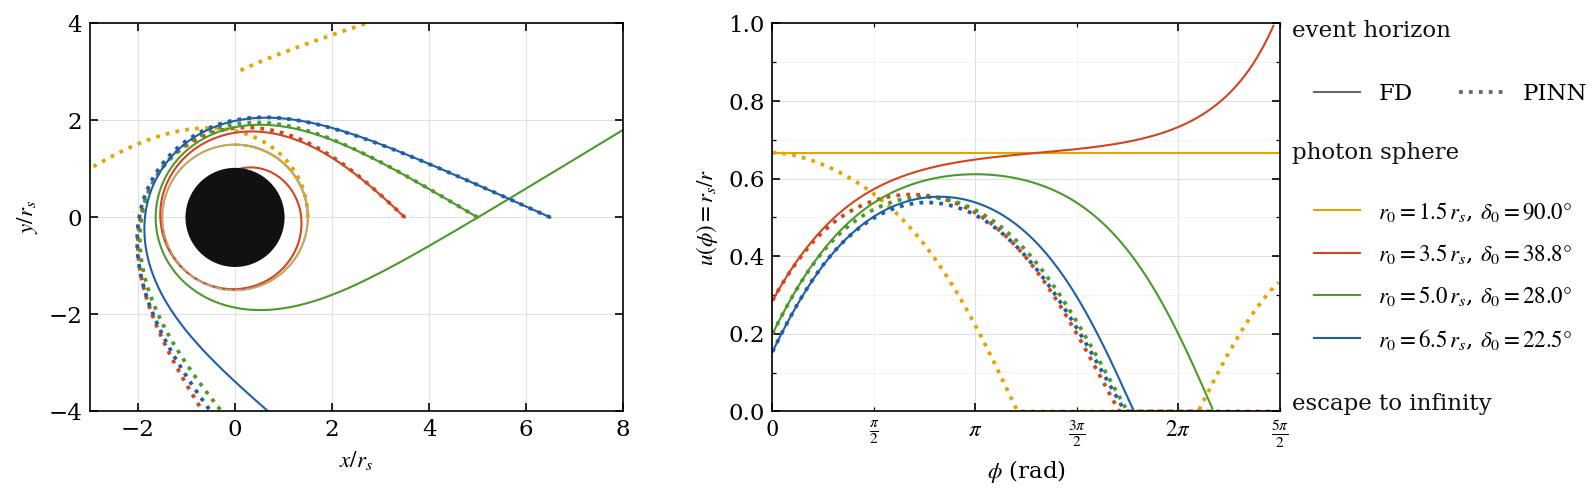

In [10]:
# Overlay FD + PINN, Δφ = φmax (no slicing)
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=phi_max, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Figure 3: Domain Slicing Strategy
Illustration of the slicing strategy: three orbits (FD solver) shown
over the full φ range, with three overlaid on side panels within one
φ-slice.

Saved: figures/uphi_segment_panels_pi-over-2.pdf


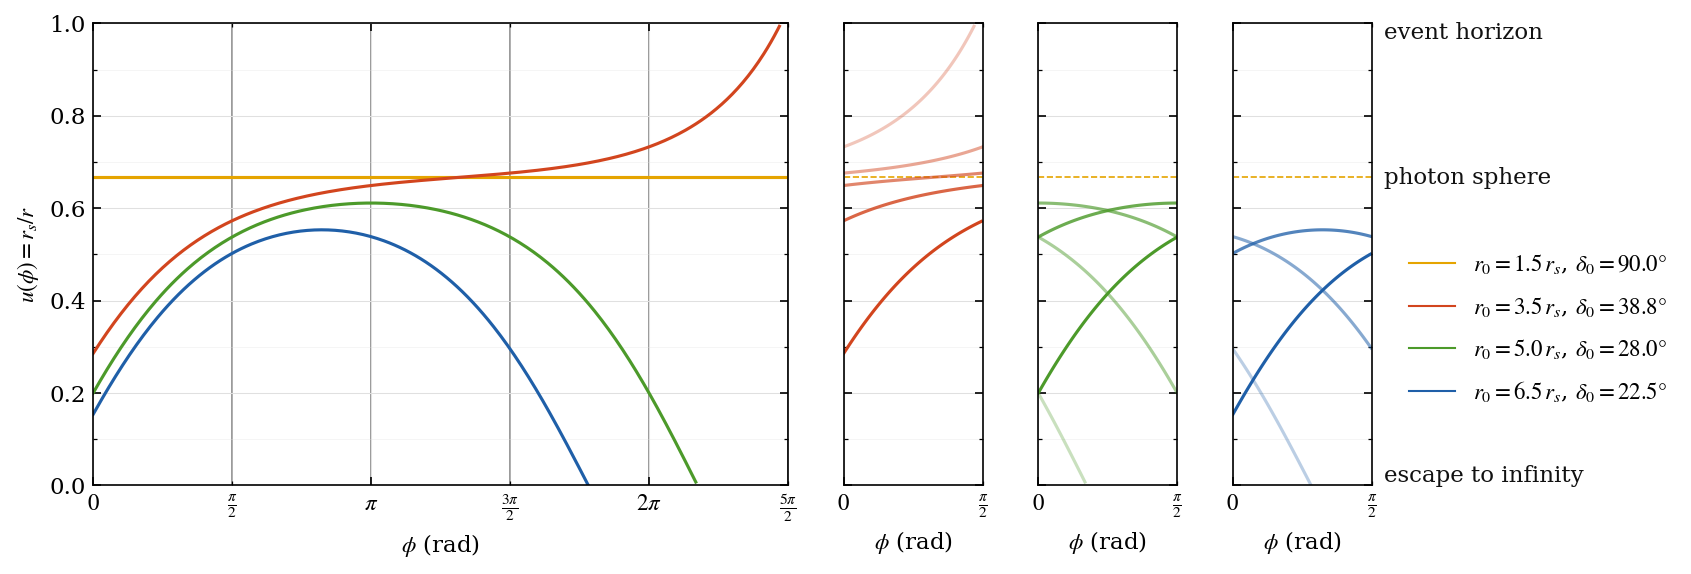

In [11]:
# Removing the photon sphere (irrelevant for the illustration)
orbits_panels = [orb for orb in DEMO_ORBITS if orb['delta'] != 90][:3]

# Overlaying FD orbit segments of width [0 pi/2]
plot_uphi_with_segment_panels(DEMO_ORBITS, orbits_panels, np.pi/2, phi_max,
                              fd_solver=fd_solver,
                              name='uphi_segment_panels_pi-over-2',
                              save=True, savedir=FIG_DIR)
plt.show()


### Section 4: Results

#### ↳ Figure 4: FD + PINN comparison, Δφ = 0.1
Solutions of PINN-Slicer, trained and recursively deployed over the
φ-slice [0, Δφ], Δφ = 0.1, closely matching the finite-difference (FD)
reference.


Loading PINN model from parameter file: /Users/cdavid/Workarea/ml/pinn_project/pinnslicer/runs/dphi010/dphi010_params.pth



Saved: figures/xy_uphi_fd_pinn_dphi010_demo.pdf


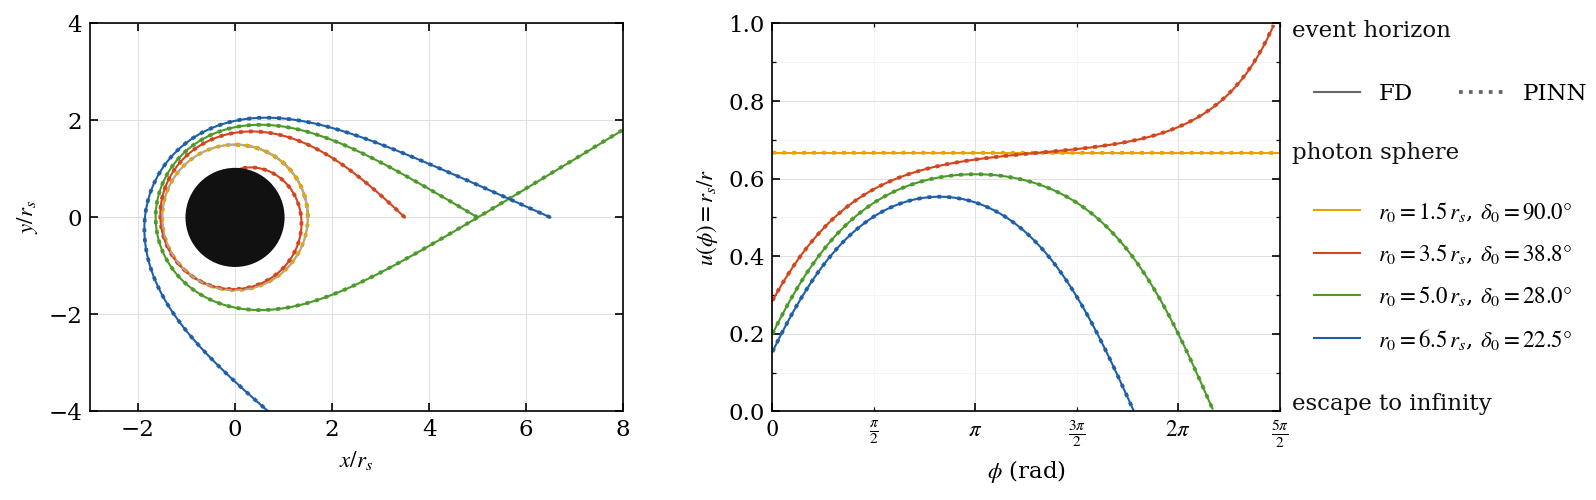

In [12]:
# Overlay FD + PINN, Δφ = 0.1
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=0.1, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Table 1: RMSE & Solution Domain

In [13]:
print_result_table(DEMO_ORBITS, fd_data_demo, pinn_data)


            r0     delta        u0        v0     rmse_u     rmse_v   phi_reached   iters   type                     status    
----------------------------------------------------------------------------------------------------------------------------------
   0      1.50   90.0000    0.6667      0.00   1.44e-04   1.45e-04         7.854      79   photon sphere            COMPLETED 
   1      3.50   38.8200    0.2857      0.30   3.38e-04   4.07e-04         7.756      78   inward spiral            ABSORBED  
   2      5.00   27.9937    0.2000      0.34   8.43e-05   4.52e-05         6.811      69   escaping to outer space  ESCAPED   
   3      6.50   22.5000    0.1538      0.34   1.68e-05   1.65e-05         5.590      56   escaping to outer space  ESCAPED   


### Appendices

### Appendix B: PINN Failure with Boomerang Orbits

#### ↳ Figure 6: FD + PINN, boomerang orbits


Loading PINN model from parameter file: /Users/cdavid/Workarea/ml/pinn_project/pinnslicer/runs/five_pi_by_2/pinn_params.pth



Saved: figures/xy_uphi_fd_pinn_five_pi_by_2_no_slicing_boomerang.pdf


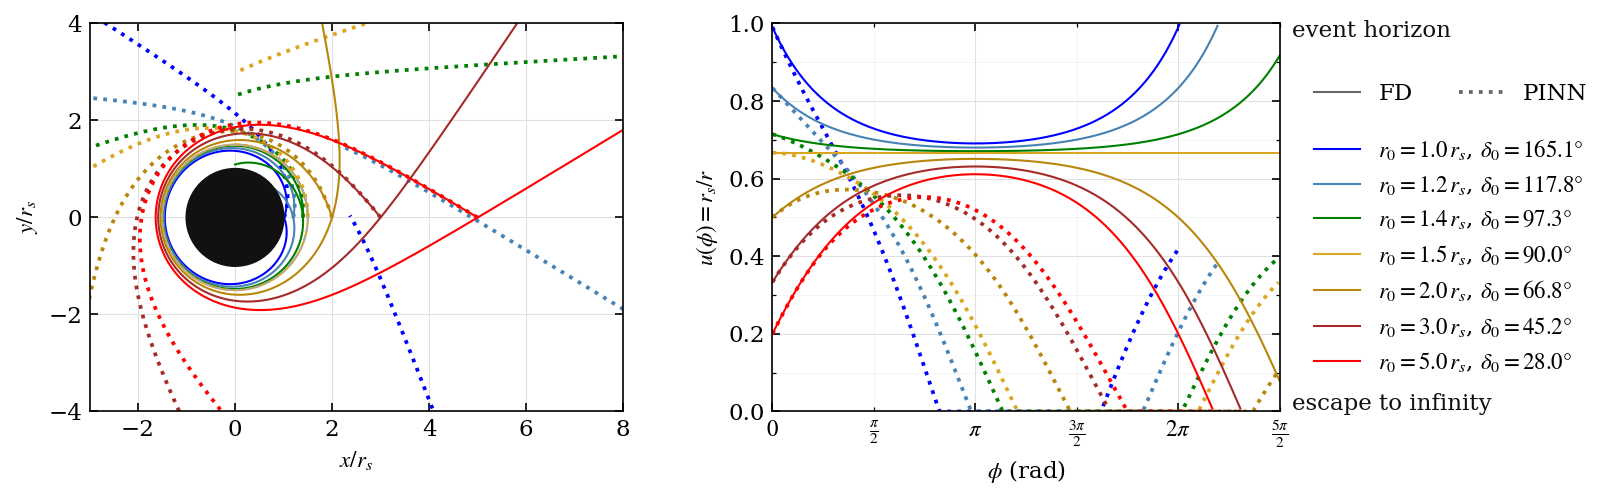

In [14]:
# Get reference solutions with boomerang orbits
fd_data_boomerang = {}
for orb in BOOMERANG_ORBITS:
    fd_data_boomerang[(orb['r0'], orb['delta'])] = fd_solver(
        (orb['u0'], orb['v0']), phi)

# FD + PINN solution,  Δφ = φmax (no slicing) with boomerang orbits
pinn_data = run_pinn_comparison(BOOMERANG_ORBITS, fd_data_boomerang,
                                dphi=phi_max,
                                phi_max=phi_max,
                                orbit_label='boomerang',
                                legend_anchor=(1.05, 0.73),
                                save=True)


### Appendix C: Validation loss across training segments

#### ↳ Figure 7: Final average loss vs Δφ
Final average validation loss as a function of the training segment width ∆ϕ.

Training was run separately (not reproduced in this notebook)

  dphi   geometric mean     band lower     band upper
  0.05       7.6491e-10     1.9562e-10     2.9910e-09
  0.10       2.0343e-10     1.6623e-10     2.4896e-10
  0.20       5.4167e-10     2.7677e-10     1.0601e-09
  0.40       1.1607e-09     5.4643e-10     2.4655e-09
  0.80       4.2979e-09     3.3705e-09     5.4805e-09
  1.60       5.4671e-07     4.2517e-07     7.0299e-07


Saved: figures/loss_vs_dphi.pdf


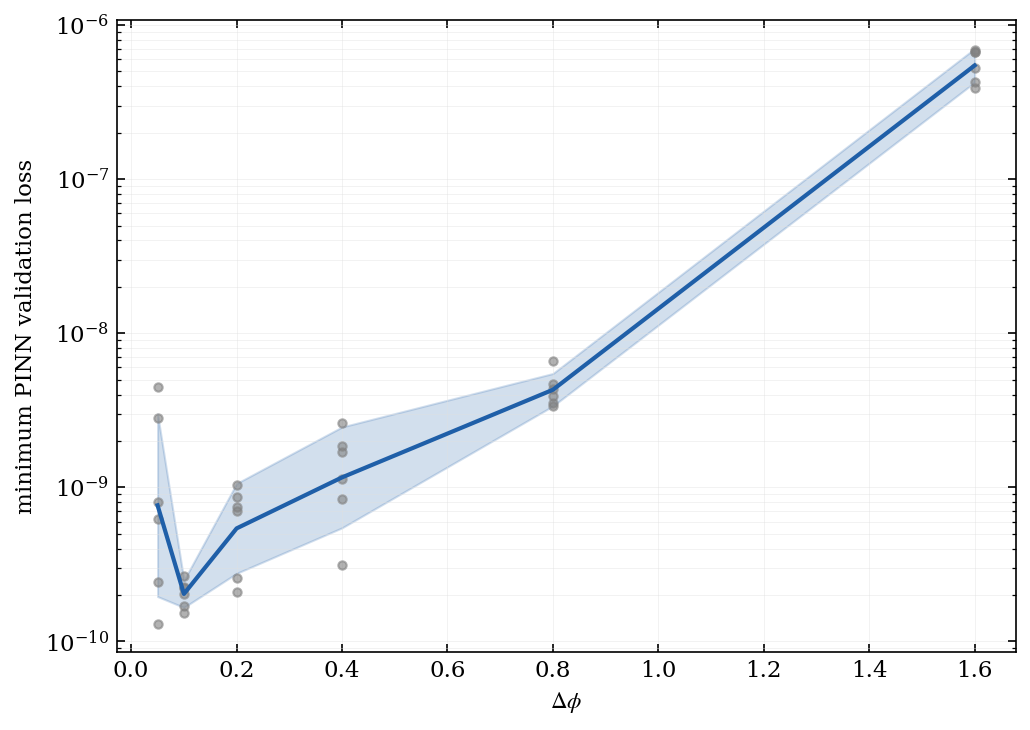

In [15]:
LOSS_VS_DPHI_RAW = {
    0.05: [1.305102e-10, 2.819534e-09, 6.222114e-10, 7.979259e-10, 2.447076e-10, 4.480317e-09],
    0.10: [1.706340e-10, 2.030031e-10, 2.653919e-10, 2.258125e-10, 1.526566e-10, 2.236567e-10],
    0.20: [2.102204e-10, 2.576394e-10, 7.423668e-10, 8.614548e-10, 7.016583e-10, 1.039313e-09],
    0.40: [1.685030e-09, 8.427916e-10, 1.127251e-09, 2.612233e-09, 3.135684e-10, 1.864791e-09],
    0.80: [3.396353e-09, 3.910152e-09, 6.584242e-09, 4.690594e-09, 3.509198e-09, 4.379387e-09],
    1.60: [6.66828e-07, 4.242561e-07, 6.663738e-07, 6.936327e-07, 3.896478e-07, 5.240802e-07],
}

# Summarised and drawn by the package (pinnslicer/utils/loss_vs_dphi.py).
#
# These losses are approximately log-normal and span three orders of
# magnitude, so both the centre line and the band are computed in log space:
# the line is the geometric mean and the band is positive by construction.
# This cell used to average in linear space, which put the lower edge of the
# band at Δφ = 0.05 below zero -- silently clipped by the log axis -- and the
# centre line a factor of 2 above the geometric mean.
dphis, centre, lower, upper = summarise(LOSS_VS_DPHI_RAW, band='std')

print(f'{"dphi":>6s} {"geometric mean":>16s} {"band lower":>14s} {"band upper":>14s}')
for d, c, lo, hi in zip(dphis, centre, lower, upper):
    print(f'{d:6.2f} {c:16.4e} {lo:14.4e} {hi:14.4e}')

plot_loss_vs_dphi(LOSS_VS_DPHI_RAW, band='std', color=COBALT,
                  name='loss_vs_dphi', save=True, outdir=FIG_DIR)
plt.show()


### Appendix D: More FD + PINN comparisons

#### ↳ Figure 8: FD and PINN-Slicer solutions for ∆ϕ = 0.05



Loading PINN model from parameter file: /Users/cdavid/Workarea/ml/pinn_project/pinnslicer/runs/dphi005/dphi005_params.pth



Saved: figures/xy_uphi_fd_pinn_dphi005_demo.pdf


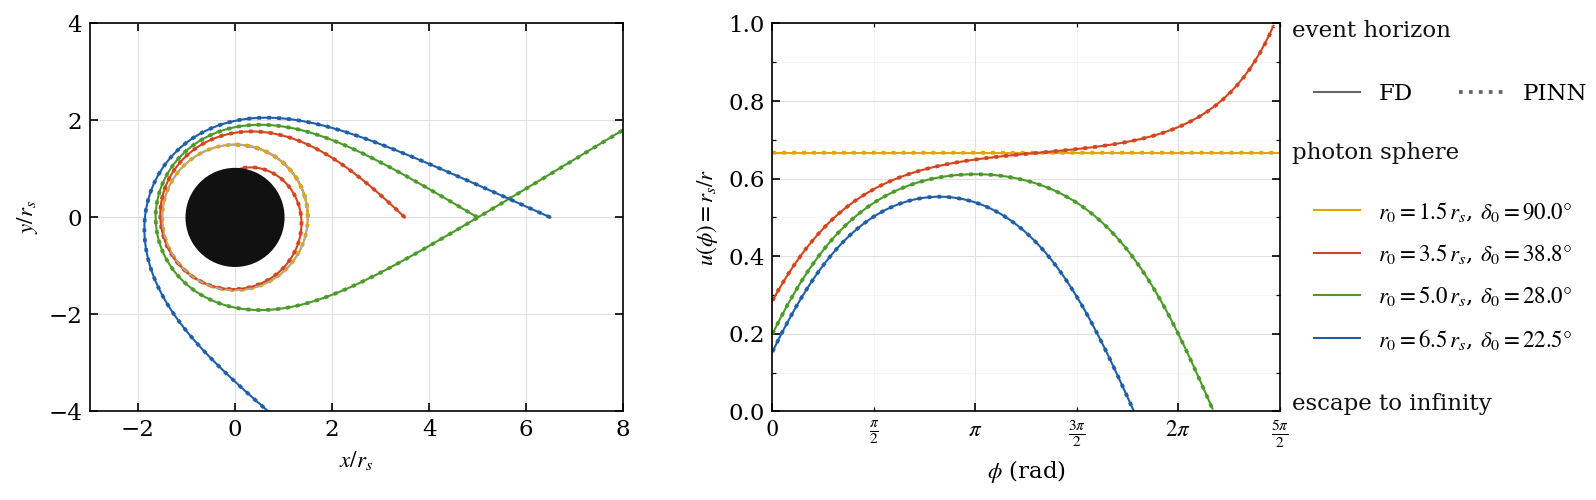

In [16]:
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=0.05, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Figure 9: FD and PINN-Slicer solutions for ∆ϕ = 0.20



Loading PINN model from parameter file: /Users/cdavid/Workarea/ml/pinn_project/pinnslicer/runs/dphi020/dphi020_params.pth



Saved: figures/xy_uphi_fd_pinn_dphi020_demo.pdf


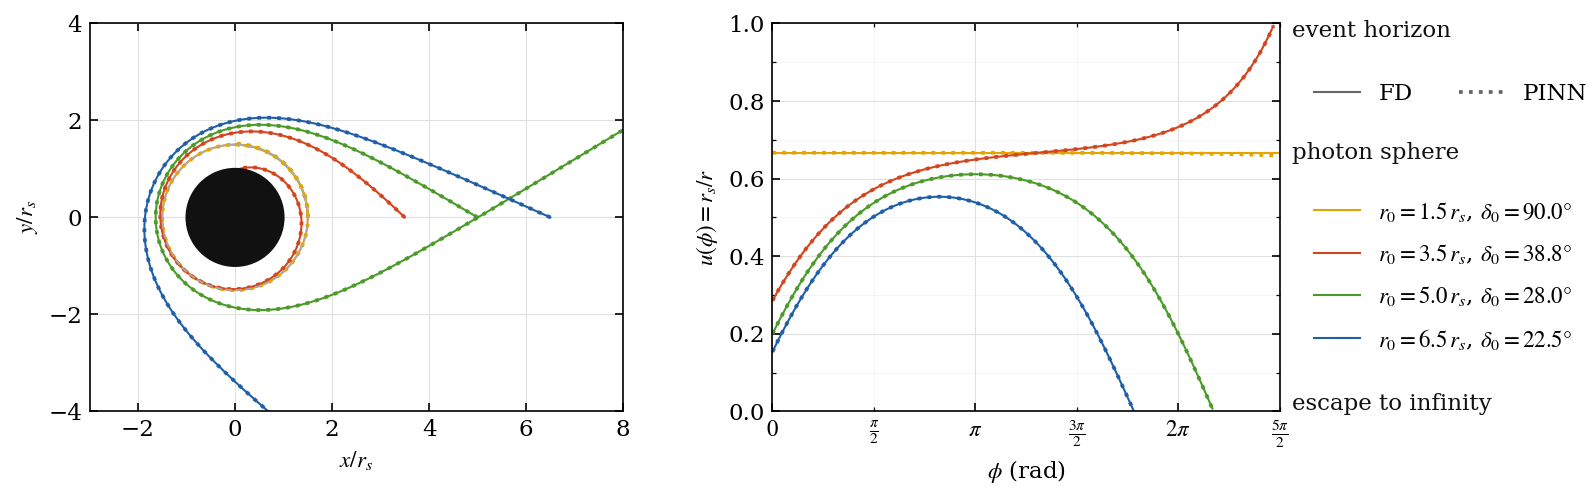

In [17]:
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=0.20, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Figure 10: FD and PINN-Slicer solutions for ∆ϕ = 0.40




Loading PINN model from parameter file: /Users/cdavid/Workarea/ml/pinn_project/pinnslicer/runs/dphi040/dphi040_params.pth



Saved: figures/xy_uphi_fd_pinn_dphi040_demo.pdf


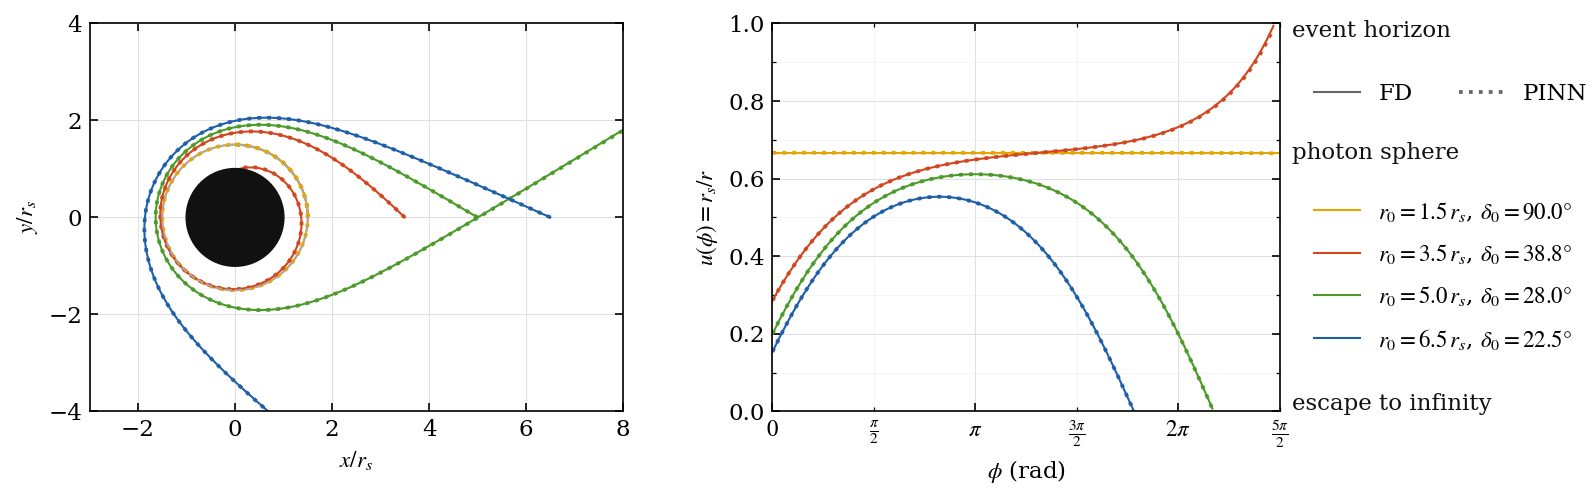

In [18]:
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=0.40, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Figure 11: FD and PINN-Slicer solutions for ∆ϕ = 0.8


Loading PINN model from parameter file: /Users/cdavid/Workarea/ml/pinn_project/pinnslicer/runs/dphi080/dphi080_params.pth



Saved: figures/xy_uphi_fd_pinn_dphi080_demo.pdf


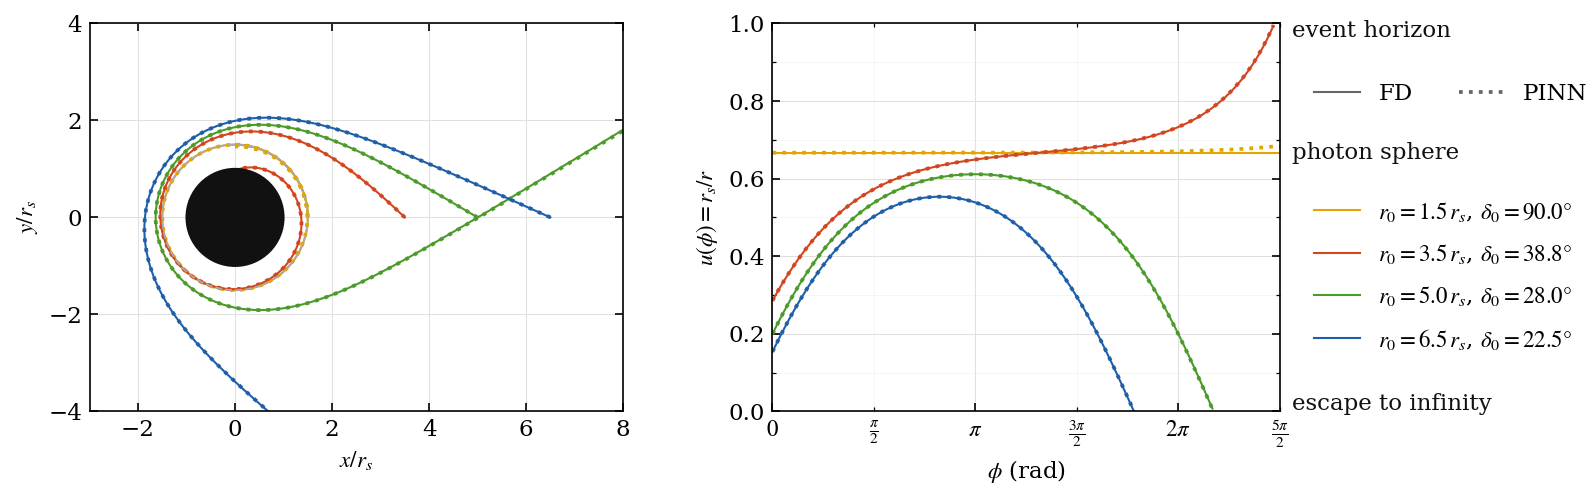

In [19]:
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=0.80, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Figure 12: FD and PINN-Slicer solutions for ∆ϕ = 1.6


Loading PINN model from parameter file: /Users/cdavid/Workarea/ml/pinn_project/pinnslicer/runs/dphi160/dphi160_params.pth



Saved: figures/xy_uphi_fd_pinn_dphi160_demo.pdf


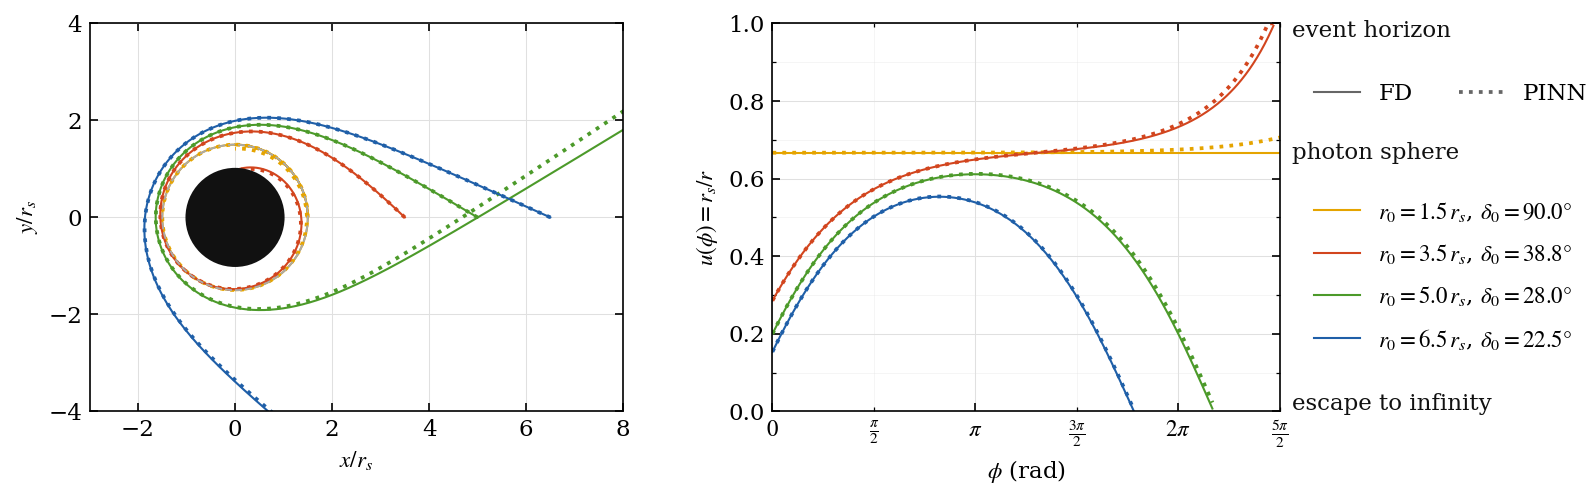

In [20]:
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=1.6, phi_max=phi_max,
                    orbit_label='demo', save=True)

## Copy to Drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

In [ ]:
!cp -r figures /content/gdrive/MyDrive/Research/ML4PS2026/pinn_plots/